***Mo hinh CNN***

In [2]:
# ============================
# B22DCCN476 - Đỗ Ngọc Lâm 
# ============================

import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_model(input_shape=(64, 64, 3), num_classes=10):
    model = models.Sequential(name="Simple_CNN")

    # --- Khối trích xuất đặc trưng ---
    # Tầng tích chập 1: học cạnh, góc, texture đơn giản
    model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu',
                            input_shape=input_shape, name="conv1"))
    model.add(layers.MaxPooling2D(pool_size=(2,2), name="pool1"))

    # Tầng tích chập 2: học đặc trưng phức tạp hơn (hình khối, bộ phận đối tượng)
    model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu',
                            name="conv2"))
    model.add(layers.MaxPooling2D(pool_size=(2,2), name="pool2"))

    # Có thể thêm 1 block nữa để sâu hơn
    model.add(layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu',
                            name="conv3"))
    model.add(layers.MaxPooling2D(pool_size=(2,2), name="pool3"))

    # --- Khối phân loại ---
    # Trải phẳng feature map thành vector
    model.add(layers.Flatten(name="flatten"))

    # Dense layer: học quan hệ giữa các đặc trưng đã trích xuất
    model.add(layers.Dense(128, activation='relu', name="fc1"))

    # Lớp đầu ra: softmax cho phân loại
    model.add(layers.Dense(num_classes, activation='softmax', name="output"))

    return model

cnn_model = build_cnn_model()
cnn_model.summary()


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Simple_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

***Mô hình RNN***

In [3]:
# ============================
# B22DCCN476
# ============================

import tensorflow as tf
from tensorflow.keras import layers, models

def build_rnn_model(timesteps=20, feature_dim=50, num_classes=5):
    """
    timesteps   = độ dài chuỗi (ví dụ: câu có 20 từ)
    feature_dim = số đặc trưng mỗi bước (ví dụ: embedding 50 chiều)
    """
    model = models.Sequential(name="Simple_RNN")

    # Tầng RNN cơ bản:
    # - đọc chuỗi theo thứ tự thời gian
    # - giữ một trạng thái ẩn để "nhớ ngắn hạn"
    model.add(layers.SimpleRNN(
        units=64,
        activation='tanh',
        return_sequences=False,  # chỉ lấy trạng thái cuối cùng
        input_shape=(timesteps, feature_dim),
        name="rnn_layer"
    ))

    # Dense cuối để ra dự đoán (ví dụ: phân loại cảm xúc câu)
    model.add(layers.Dense(64, activation='relu', name="fc1"))
    model.add(layers.Dense(num_classes, activation='softmax', name="output"))

    return model

rnn_model = build_rnn_model()
rnn_model.summary()


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_layer (SimpleRNN)           │ (None, 64)             │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,845 (46.27 KB)

 Trainable params: 11,845 (46.27 KB)

 Non-trainable params: 0 (0.00 B)

***Mô hình LSTM***

In [4]:
# ============================
#B22DCCN476
# ============================

import tensorflow as tf
from tensorflow.keras import layers, models

def build_lstm_model(timesteps=50, feature_dim=100, num_classes=5):
    """
    timesteps   = độ dài chuỗi dài hơn (ví dụ: 50 từ)
    feature_dim = số đặc trưng tại mỗi bước (ví dụ: embedding 100 chiều)
    """
    model = models.Sequential(name="Simple_LSTM")

    # Tầng LSTM:
    # - có bộ nhớ (cell state) và các cổng (quên / ghi / xuất)
    # - giữ được thông tin dài hạn trong chuỗi
    model.add(layers.LSTM(
        units=128,
        return_sequences=False,   # lấy trạng thái cuối cùng
        input_shape=(timesteps, feature_dim),
        name="lstm_layer"
    ))

    # Dense cuối (phân loại, dự báo, v.v.)
    model.add(layers.Dense(128, activation='relu', name="fc1"))
    model.add(layers.Dense(num_classes, activation='softmax', name="output"))

    return model

lstm_model = build_lstm_model()
lstm_model.summary()


Model: "Simple_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer (LSTM)               │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,405 (525.02 KB)

 Trainable params: 134,405 (525.02 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Cell #1: Import & global config
# Đỗ Ngọc Lâm - B22DCCN476
# --------------------------------
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models

# Để kết quả tái lập
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Đường dẫn file CSV thời tiết
DATA_PATH = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\ktra2\DATA\weather_vietnam2\df_weather.csv"

# Các thành phố cần dự báo
CITIES = ["Hà Nội", "Đà Nẵng", "TP. Hồ Chí Minh"]

# Độ dài chuỗi đầu vào (7 ngày gần nhất)
SEQ_LEN = 7

# Cột dùng làm nhãn (giá trị cần dự báo)
TARGET_COL = "day.maxtemp_c"

# Một số hàm tiện ích sẽ viết ở cell sau
print("✅ Cell #1 OK: thư viện đã import.")


✅ Cell #1 OK: thư viện đã import.


In [6]:
# Cell #2: Load & filter cities
# Đỗ Ngọc Lâm - B22DCCN476
# -----------------------------
df = pd.read_csv(DATA_PATH)

# Chuẩn hoá tên cột cho dễ dùng
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

# Ép kiểu date -> datetime, sort theo thời gian
df["date"] = pd.to_datetime(df["date"])

# Lọc chỉ 3 thành phố quan tâm
df_city = df[df["location.name"].isin(CITIES)].copy()

# Sắp xếp theo từng thành phố và ngày
df_city = df_city.sort_values(by=["location.name", "date"]).reset_index(drop=True)

print("Dữ liệu 3 thành phố:")
print(df_city[["location.name","date","day.maxtemp_c","day.mintemp_c","day.avgtemp_c",
               "day.avghumidity","day.daily_will_it_rain","day.daily_chance_of_rain"]].head(15))
print("Số dòng mỗi city:")
print(df_city["location.name"].value_counts())


Dữ liệu 3 thành phố:
   location.name       date  day.maxtemp_c  day.mintemp_c  day.avgtemp_c  \
0         Hà Nội 2024-04-21           32.2           25.4           28.4   
1         Hà Nội 2024-04-22           32.1           24.4           27.8   
2         Hà Nội 2024-04-23           29.7           25.2           26.8   
3         Hà Nội 2024-04-24           30.2           23.4           26.3   
4         Hà Nội 2024-04-25           35.8           23.8           28.3   
5         Hà Nội 2024-04-26           37.1           25.0           29.9   
6         Hà Nội 2024-04-27           42.5           25.6           32.4   
7         Hà Nội 2024-04-28           39.2           25.9           31.2   
8         Hà Nội 2024-04-29           40.0           26.0           31.7   
9         Hà Nội 2024-04-30           39.9           26.7           32.5   
10        Hà Nội 2024-05-01           29.1           24.6           27.2   
11        Hà Nội 2024-05-02           26.8           22.9          

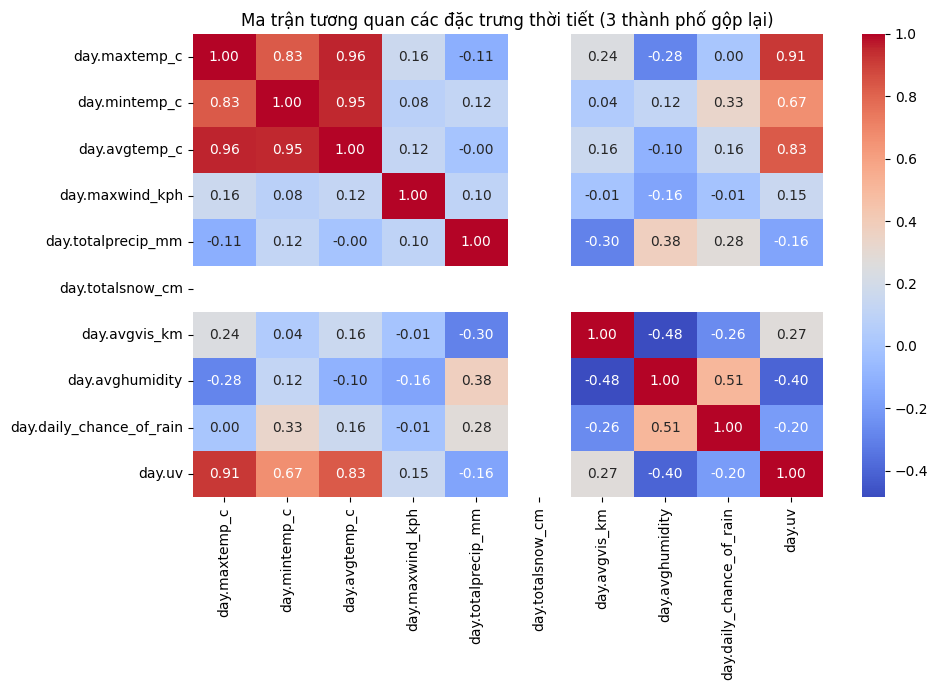

Nhận xét nhanh:
- Hệ số tương quan gần 1 hoặc -1 => liên hệ mạnh.
- Ta kỳ vọng 'day.avgtemp_c' và 'day.mintemp_c' sẽ tương quan cao với 'day.maxtemp_c'.


In [7]:
# Cell #3: Correlation matrix
# Đỗ Ngọc Lâm - B22DCCN476
# ---------------------------
import seaborn as sns

# Các feature numeric tiềm năng
num_cols = [
    "day.maxtemp_c",
    "day.mintemp_c",
    "day.avgtemp_c",
    "day.maxwind_kph",
    "day.totalprecip_mm",
    "day.totalsnow_cm",
    "day.avgvis_km",
    "day.avghumidity",
    "day.daily_chance_of_rain",
    "day.uv"
]

corr_data = df_city[num_cols].corr(method="pearson")

plt.figure(figsize=(10,7))
sns.heatmap(corr_data, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Ma trận tương quan các đặc trưng thời tiết (3 thành phố gộp lại)")
plt.tight_layout()
plt.show()

print("Nhận xét nhanh:")
print("- Hệ số tương quan gần 1 hoặc -1 => liên hệ mạnh.")
print("- Ta kỳ vọng 'day.avgtemp_c' và 'day.mintemp_c' sẽ tương quan cao với 'day.maxtemp_c'.")


In [8]:
# Cell #4: Hàm tạo dataset chuỗi thời gian
# Đỗ Ngọc Lâm - B22DCCN476
# ----------------------------------------

def build_city_sequences(df_city_single,
                         feature_cols,
                         target_col=TARGET_COL,
                         seq_len=SEQ_LEN,
                         test_ratio=0.2):
    """
    df_city_single: dataframe chỉ chứa 1 thành phố, đã sort theo date tăng dần.
    feature_cols: list tên cột feature numeric.
    target_col: cột cần dự báo (scalar).
    seq_len: số ngày quá khứ dùng để dự đoán.
    test_ratio: tỉ lệ tách test theo thời gian (cuối chuỗi).
    
    return:
      X_train, y_train, X_val, y_val, X_test, y_test, scaler
    """
    df_single = df_city_single.copy().reset_index(drop=True)

    # Chỉ giữ các cột cần thiết (features + target + date để tham khảo)
    data_feat = df_single[feature_cols].values.astype("float32")
    data_target = df_single[target_col].values.astype("float32")

    # Scale toàn bộ feature theo MinMax cho thành phố này (giữ riêng scaler cho từng city)
    scaler = MinMaxScaler()
    data_feat_scaled = scaler.fit_transform(data_feat)

    # Tạo các sample chuỗi
    X_list = []
    y_list = []

    for i in range(len(df_single) - seq_len):
        X_seq = data_feat_scaled[i:i+seq_len]              # seq_len x num_features
        y_next = data_target[i+seq_len]                    # giá trị ngày kế
        X_list.append(X_seq)
        y_list.append(y_next)

    X = np.array(X_list)  # (N, seq_len, num_feat)
    y = np.array(y_list)  # (N, )

    # Chia train/val/test theo tỉ lệ thời gian 60/20/20 (train/val/test)
    N = len(X)
    N_test = int(N * test_ratio)
    N_val = int((N - N_test) * 0.2)  # 20% của (train+val) cho val
    N_train = N - N_test - N_val

    X_train, y_train = X[:N_train], y[:N_train]
    X_val,   y_val   = X[N_train:N_train+N_val], y[N_train:N_train+N_val]
    X_test,  y_test  = X[N_train+N_val:], y[N_train+N_val:]

    print(f"[{df_city_single['location.name'].iloc[0]}] shapes:",
          "X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)

    return X_train, y_train, X_val, y_val, X_test, y_test, scaler


# Ta chọn bộ feature đầu vào (KHÔNG gồm target_col lặp lại)
feature_cols = [
    "day.mintemp_c",
    "day.avgtemp_c",
    # "day.maxwind_kph",
    "day.totalprecip_mm",
    # "day.totalsnow_cm",
    # # "day.avgvis_km",
    "day.avghumidity",
    "day.daily_chance_of_rain",
    "day.uv"
]

# Chuẩn bị dict lưu dataset cho từng city
datasets = {}

for city in CITIES:
    sub = df_city[df_city["location.name"] == city].sort_values("date")
    X_tr, y_tr, X_val, y_val, X_te, y_te, sc = build_city_sequences(
        sub,
        feature_cols=feature_cols,
        target_col=TARGET_COL,
        seq_len=SEQ_LEN,
        test_ratio=0.2
    )
    datasets[city] = {
        "X_train": X_tr, "y_train": y_tr,
        "X_val": X_val, "y_val": y_val,
        "X_test": X_te, "y_test": y_te,
        "scaler": sc,
        "n_features": len(feature_cols)
    }


[Hà Nội] shapes: X_train (260, 7, 6) X_val (65, 7, 6) X_test (81, 7, 6)
[Đà Nẵng] shapes: X_train (260, 7, 6) X_val (65, 7, 6) X_test (81, 7, 6)
[TP. Hồ Chí Minh] shapes: X_train (260, 7, 6) X_val (65, 7, 6) X_test (81, 7, 6)


In [9]:
# Cell #5 (LIGHT VERSION): Định nghĩa mô hình RNN & LSTM (đơn giản, hiệu quả)
# Đỗ Ngọc Lâm - B22DCCN476
# -------------------------------------------------
from tensorflow.keras import layers, models, optimizers, metrics

def build_model_RNN(input_shape, lr=1e-3):
    """RNN hồi quy đơn giản: 1 tầng RNN + Dropout + Dense"""
    model = models.Sequential([
        layers.SimpleRNN(64, activation="tanh", input_shape=input_shape),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=optimizers.Adam(lr),
        loss="mse",
        metrics=[metrics.MeanAbsoluteError(name="mae"),
                 metrics.MeanSquaredError(name="mse")]
    )
    return model


def build_model_LSTM(input_shape, lr=1e-3):
    """LSTM hồi quy đơn giản: 1 tầng LSTM + Dropout + Dense"""
    model = models.Sequential([
        layers.LSTM(64, activation="tanh", input_shape=input_shape),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=optimizers.Adam(lr),
        loss="mse",
        metrics=[metrics.MeanAbsoluteError(name="mae"),
                 metrics.MeanSquaredError(name="mse")]
    )
    return model

print("✅ Mô hình RNN & LSTM đơn giản hóa xong (nhanh hơn, dễ hội tụ).")


✅ Mô hình RNN & LSTM đơn giản hóa xong (nhanh hơn, dễ hội tụ).


In [10]:
# Cell #6: Train RNN & LSTM cho từng thành phố
# Đỗ Ngọc Lâm - B22DCCN476
# --------------------------------------------
# from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# cbs = [
#     EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
#     ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True)
# ]

# hist = model.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     epochs=200,
#     batch_size=16,
#     callbacks=cbs,
#     verbose=0
# )

EPOCHS = 100
BATCH_SIZE = 32
results = {}

for city in CITIES:
    data = datasets[city]
    X_train, y_train = data["X_train"], data["y_train"]
    X_val,   y_val   = data["X_val"],   data["y_val"]
    X_test,  y_test  = data["X_test"],  data["y_test"]

    input_shape = (X_train.shape[1], X_train.shape[2])

    # ----- RNN -----
    rnn_model = build_model_RNN(input_shape)
    hist_rnn = rnn_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        # callbacks=cbs,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    # Evaluate trên tập test
    y_pred_rnn = rnn_model.predict(X_test).flatten()
    mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
    mse_rnn = mean_squared_error(y_test, y_pred_rnn)
    rmse_rnn = math.sqrt(mse_rnn)

    # ----- LSTM -----
    lstm_model = build_model_LSTM(input_shape)
    hist_lstm = lstm_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        # callbacks=cbs,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    y_pred_lstm = lstm_model.predict(X_test).flatten()
    mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
    mse_lstm = mean_squared_error(y_test, y_pred_lstm)
    rmse_lstm = math.sqrt(mse_lstm)

    # Lưu lại mọi thứ để sử dụng ở cell vẽ/so sánh
    results[city] = {
        "rnn": {
            "model": rnn_model,
            "history": hist_rnn.history,
            "y_test": y_test,
            "y_pred": y_pred_rnn,
            "mae": mae_rnn, "mse": mse_rnn, "rmse": rmse_rnn,
        },
        "lstm": {
            "model": lstm_model,
            "history": hist_lstm.history,
            "y_test": y_test,
            "y_pred": y_pred_lstm,
            "mae": mae_lstm, "mse": mse_lstm, "rmse": rmse_lstm,
        }
    }

    print(f"=== {city} ===")
    print("RNN  -> MAE: %.3f | MSE: %.3f | RMSE: %.3f" % (mae_rnn, mse_rnn, rmse_rnn))
    print("LSTM -> MAE: %.3f | MSE: %.3f | RMSE: %.3f" % (mae_lstm, mse_lstm, rmse_lstm))


Epoch 1/100


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 829.5281 - mae: 28.4238 - mse: 829.5281 - val_loss: 352.6750 - val_mae: 18.4301 - val_mse: 352.6750
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 626.9199 - mae: 24.6023 - mse: 626.9199 - val_loss: 216.2215 - val_mae: 14.2700 - val_mse: 216.2215
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 436.2742 - mae: 20.3499 - mse: 436.2742 - val_loss: 102.0550 - val_mae: 9.4762 - val_mse: 102.0550
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 266.1361 - mae: 15.5416 - mse: 266.1361 - val_loss: 34.4175 - val_mae: 5.0079 - val_mse: 34.4175
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 151.1954 - mae: 11.2895 - mse: 151.1954 - val_loss: 12.2793 - val_mae: 2.9968 - val_mse: 12.2793
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 69.7645 - mae: 7.3705 - mse: 69.7645 - val_loss: 24.0598 - val_mae: 3.9465 - val_mse: 24.0598
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 38.5729 - mae: 5.2645 - m

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 912.3104 - mae: 29.8530 - mse: 912.3104 - val_loss: 477.9062 - val_mae: 21.5767 - val_mse: 477.9062
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 866.6113 - mae: 29.0968 - mse: 866.6113 - val_loss: 445.7040 - val_mae: 20.8076 - val_mse: 445.7040
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 779.5718 - mae: 27.5884 - mse: 779.5718 - val_loss: 370.4394 - val_mae: 18.8801 - val_mse: 370.4394
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 615.1296 - mae: 24.4366 - mse: 615.1296 - val_loss: 230.7953 - val_mae: 14.6918 - val_mse: 230.7953
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 421.9488 - mae: 20.0470 - mse: 421.9488 - val_loss: 108.3970 - val_mae: 9.7358 - val_mse: 108.3970
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 268.3644 - mae: 15.6840 - mse: 268.3644 - val_loss: 40.7336 - val_mae: 5.5089 - val_mse: 40.7336
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 152.5910 -

...

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 896.6824 - mae: 29.5926 - mse: 896.6824 - val_loss: 550.6628 - val_mae: 23.3257 - val_mse: 550.6628
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 850.1794 - mae: 28.8042 - mse: 850.1794 - val_loss: 510.1396 - val_mae: 22.4455 - val_mse: 510.1396
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 751.7959 - mae: 27.0472 - mse: 751.7959 - val_loss: 405.7476 - val_mae: 19.9963 - val_mse: 405.7476
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 560.1660 - mae: 23.2061 - mse: 560.1660 - val_loss: 232.2323 - val_mae: 15.0487 - val_mse: 232.2323
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 350.2097 - mae: 18.1006 - mse: 350.2097 - val_loss: 93.6689 - val_mae: 9.3619 - val_mse: 93.6689
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 187.9482 - mae: 12.7878 - mse: 187.9482 - val_loss: 22.8711 - val_mae: 4.0968 - val_mse: 22.8711
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 84.1643 - mae: 7

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 978.7048 - mae: 31.1780 - mse: 978.7048 - val_loss: 1082.3688 - val_mae: 32.8523 - val_mse: 1082.3688
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 856.4302 - mae: 29.1470 - mse: 856.4302 - val_loss: 929.2626 - val_mae: 30.4305 - val_mse: 929.2626
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 703.3358 - mae: 26.3773 - mse: 703.3358 - val_loss: 735.6776 - val_mae: 27.0624 - val_mse: 735.6776
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 536.9819 - mae: 23.0108 - mse: 536.9819 - val_loss: 558.3357 - val_mae: 23.5588 - val_mse: 558.3357
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 389.2810 - mae: 19.5343 - mse: 389.2810 - val_loss: 399.8611 - val_mae: 19.9140 - val_mse: 399.8611
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 260.0698 - mae: 15.8326 - mse: 260.0698 - val_loss: 267.0649 - val_mae: 16.2414 - val_mse: 267.0649
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 156.2127 -

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 986.0337 - mae: 31.2964 - mse: 986.0337 - val_loss: 1129.7081 - val_mae: 33.5653 - val_mse: 1129.7081
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 909.3036 - mae: 30.0453 - mse: 909.3036 - val_loss: 1042.1128 - val_mae: 32.2362 - val_mse: 1042.1128
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 739.2272 - mae: 27.0472 - mse: 739.2272 - val_loss: 812.4932 - val_mae: 28.4421 - val_mse: 812.4932
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 470.5934 - mae: 21.4750 - mse: 470.5934 - val_loss: 479.8004 - val_mae: 21.8288 - val_mse: 479.8004
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 257.8392 - mae: 15.7722 - mse: 257.8392 - val_loss: 245.2279 - val_mae: 15.5672 - val_mse: 245.2279
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 114.7418 - mae: 10.2122 - mse: 114.7418 - val_loss: 112.0694 - val_mae: 10.4451 - val_mse: 112.0694
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 47.0458 

### Hà Nội - RNN ###


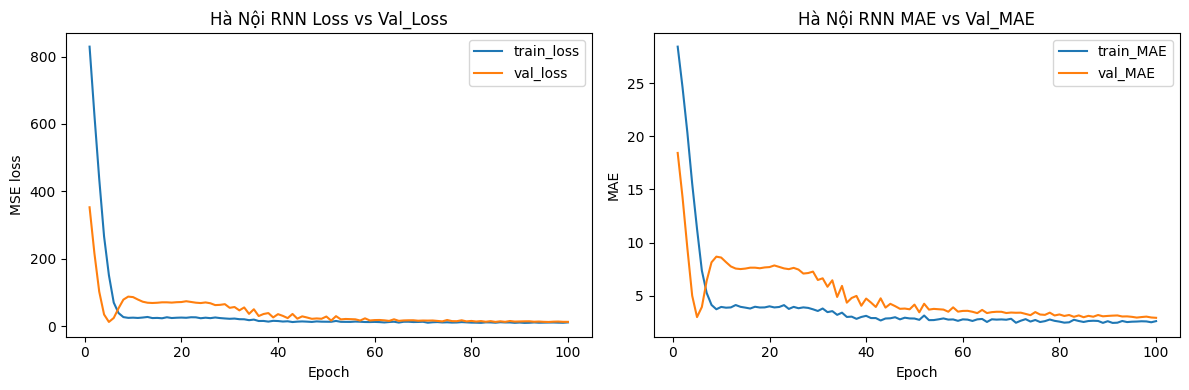

### Hà Nội - LSTM ###


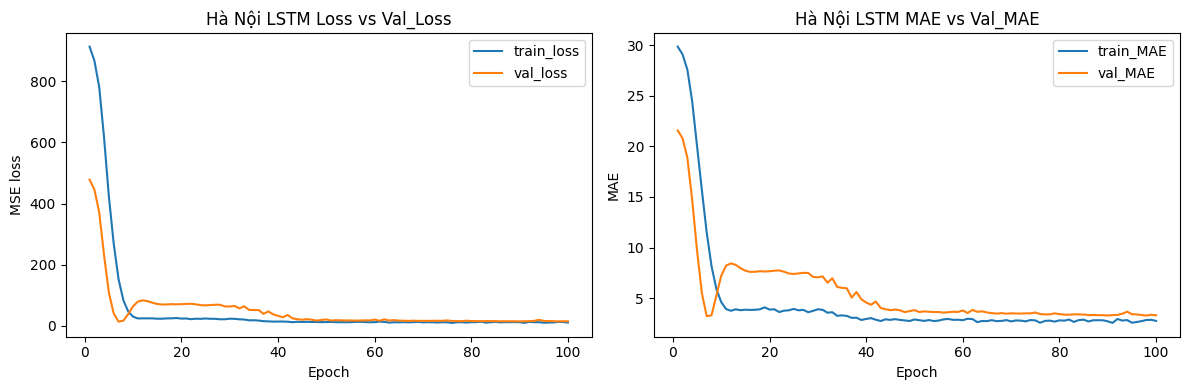

### Đà Nẵng - RNN ###


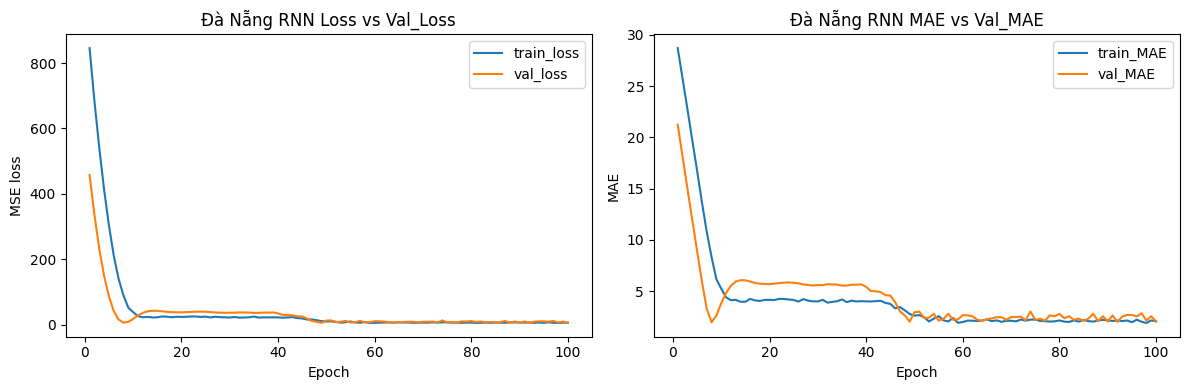

### Đà Nẵng - LSTM ###


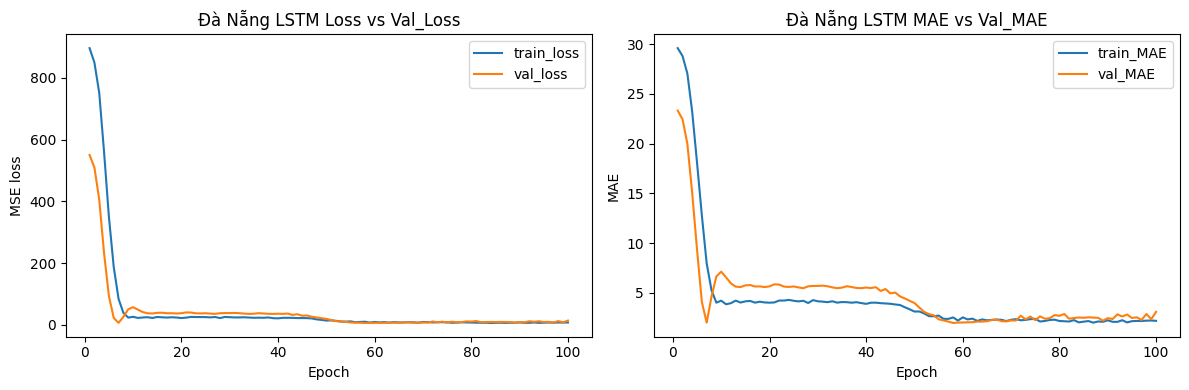

### TP. Hồ Chí Minh - RNN ###


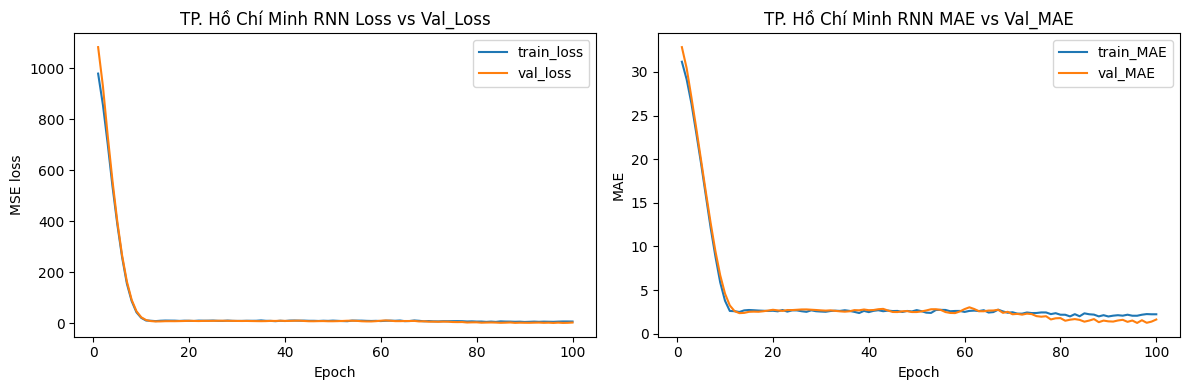

### TP. Hồ Chí Minh - LSTM ###


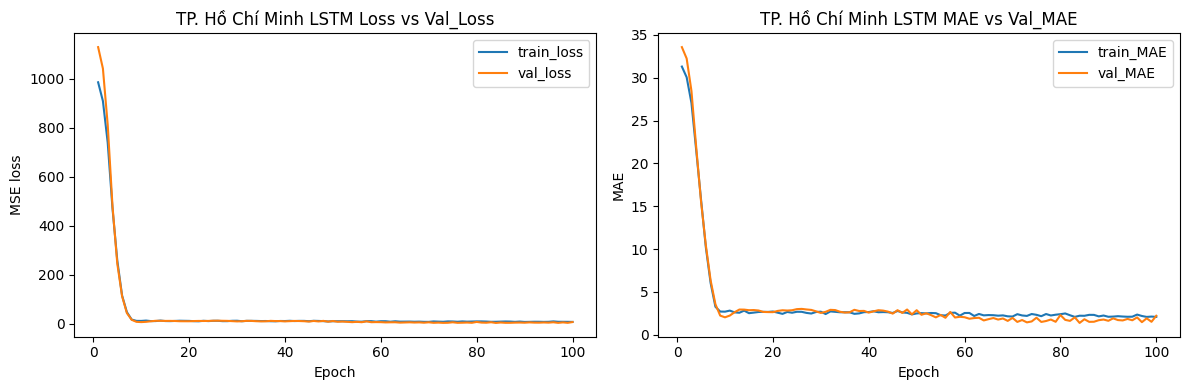

In [11]:
# Cell #7: Plot training curves
#B22DCCN476
# -----------------------------

def plot_history(history_dict, title_prefix=""):
    # history_dict = results[city]["rnn"]["history"] ...
    loss      = history_dict["loss"]
    val_loss  = history_dict["val_loss"]
    mae       = history_dict["mae"]
    val_mae   = history_dict["val_mae"]

    epochs_range = range(1, len(loss)+1)

    plt.figure(figsize=(12,4))

    # Subplot 1: Loss
    plt.subplot(1,2,1)
    plt.plot(epochs_range, loss, label="train_loss")
    plt.plot(epochs_range, val_loss, label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(f"{title_prefix} Loss vs Val_Loss")
    plt.legend()

    # Subplot 2: MAE
    plt.subplot(1,2,2)
    plt.plot(epochs_range, mae, label="train_MAE")
    plt.plot(epochs_range, val_mae, label="val_MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title(f"{title_prefix} MAE vs Val_MAE")
    plt.legend()

    plt.tight_layout()
    plt.show()


for city in CITIES:
    print(f"### {city} - RNN ###")
    plot_history(results[city]["rnn"]["history"], title_prefix=f"{city} RNN")
    print(f"### {city} - LSTM ###")
    plot_history(results[city]["lstm"]["history"], title_prefix=f"{city} LSTM")


📋 Bảng tổng hợp chỉ số trên tập Test:


,City,Model,MAE,MSE,RMSE
0,Hà Nội,RNN,3.337,15.672,3.959
1,Hà Nội,LSTM,3.972,22.578,4.752
2,Đà Nẵng,RNN,2.090,7.784,2.790
3,Đà Nẵng,LSTM,2.931,13.957,3.736
4,TP. Hồ Chí Minh,RNN,2.101,6.028,2.455
5,TP. Hồ Chí Minh,LSTM,2.519,7.928,2.816


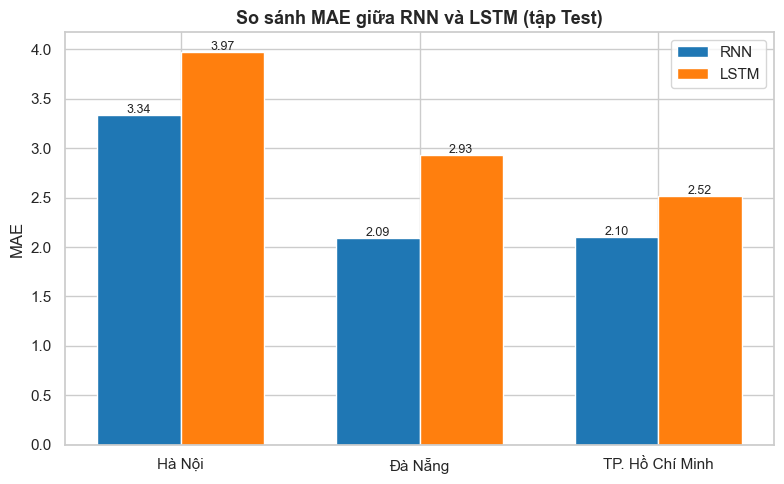

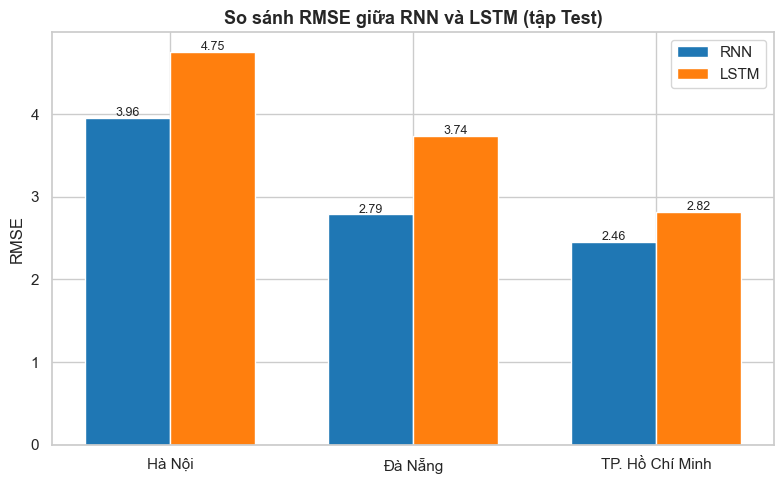

In [12]:
# Cell #8 (FINAL): Bảng và biểu đồ so sánh chỉ số cuối cùng
# Đỗ Ngọc Lâm – B22DCCN476
# ----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==== Tạo bảng kết quả ====
summary_rows = []
for city in CITIES:
    rnn_res  = results[city]["rnn"]
    lstm_res = results[city]["lstm"]
    summary_rows.append({
        "City": city,
        "Model": "RNN",
        "MAE":  rnn_res["mae"],
        "MSE":  rnn_res["mse"],
        "RMSE": rnn_res["rmse"],
    })
    summary_rows.append({
        "City": city,
        "Model": "LSTM",
        "MAE":  lstm_res["mae"],
        "MSE":  lstm_res["mse"],
        "RMSE": lstm_res["rmse"],
    })

df_summary = pd.DataFrame(summary_rows)
print("📋 Bảng tổng hợp chỉ số trên tập Test:")
display(df_summary.round(3))

# ==== Vẽ biểu đồ cột nhóm đẹp ====
sns.set(style="whitegrid", font="Arial")

metrics_to_plot = ["MAE", "RMSE"]
colors = {"RNN": "#1f77b4", "LSTM": "#ff7f0e"}

for metric in metrics_to_plot:
    plt.figure(figsize=(8,5))
    bar_width = 0.35
    x = np.arange(len(CITIES))

    rnn_vals = df_summary[df_summary["Model"]=="RNN"][metric].values
    lstm_vals = df_summary[df_summary["Model"]=="LSTM"][metric].values

    plt.bar(x - bar_width/2, rnn_vals, width=bar_width, color=colors["RNN"], label="RNN")
    plt.bar(x + bar_width/2, lstm_vals, width=bar_width, color=colors["LSTM"], label="LSTM")

    # Hiển thị giá trị trên đầu cột
    for i in range(len(CITIES)):
        plt.text(x[i]-bar_width/2, rnn_vals[i]+0.02, f"{rnn_vals[i]:.2f}", ha="center", fontsize=9)
        plt.text(x[i]+bar_width/2, lstm_vals[i]+0.02, f"{lstm_vals[i]:.2f}", ha="center", fontsize=9)

    plt.xticks(x, CITIES, fontsize=11)
    plt.ylabel(metric)
    plt.title(f"So sánh {metric} giữa RNN và LSTM (tập Test)", fontsize=13, weight='bold')
    plt.legend()
    plt.tight_layout()
    plt.show()


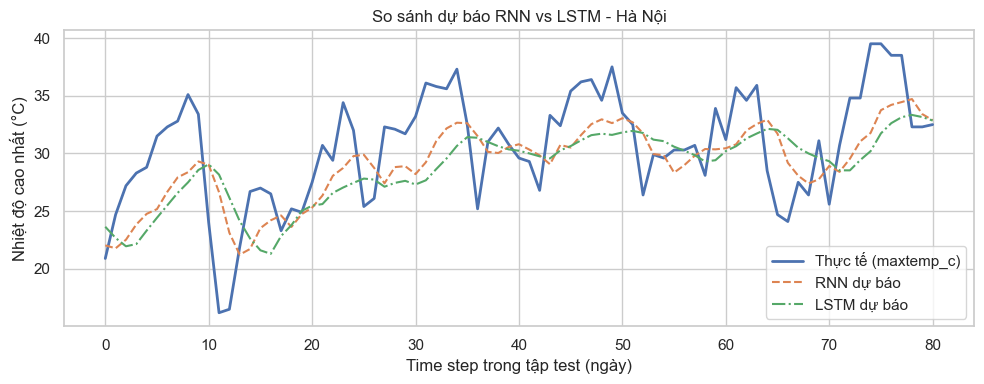

=== Hà Nội ===
RNN  -> MAE = 3.337, MSE = 15.672, RMSE = 3.959
LSTM -> MAE = 3.972, MSE = 22.578, RMSE = 4.752
--------------------------------------------------------------------------------


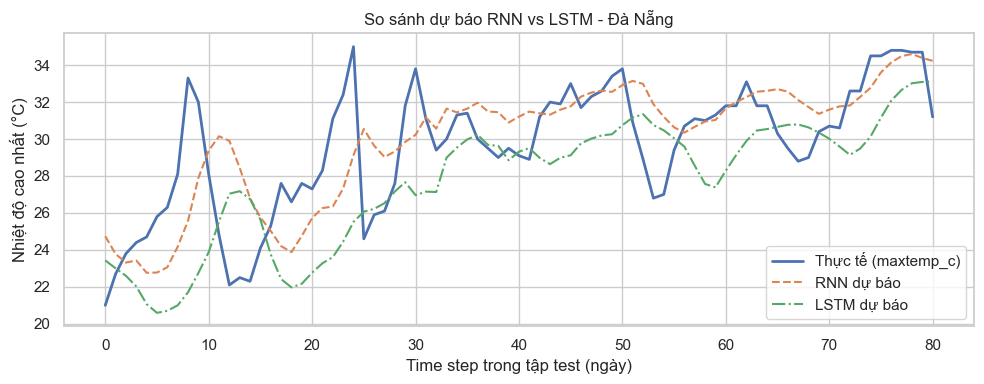

=== Đà Nẵng ===
RNN  -> MAE = 2.090, MSE = 7.784, RMSE = 2.790
LSTM -> MAE = 2.931, MSE = 13.957, RMSE = 3.736
--------------------------------------------------------------------------------


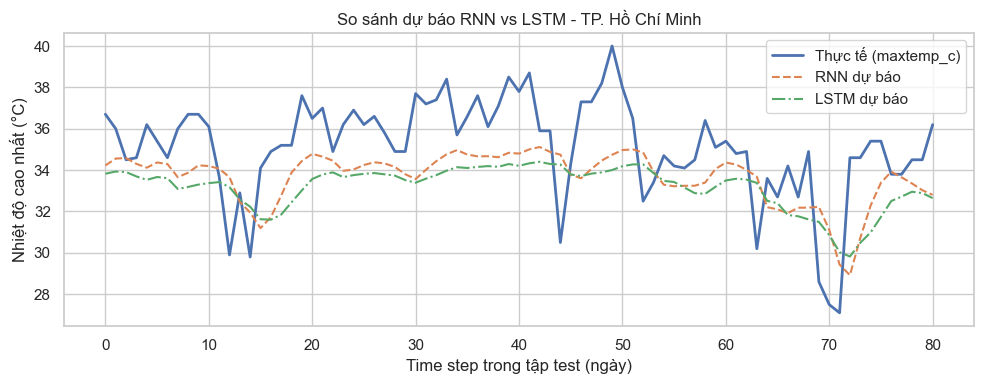

=== TP. Hồ Chí Minh ===
RNN  -> MAE = 2.101, MSE = 6.028, RMSE = 2.455
LSTM -> MAE = 2.519, MSE = 7.928, RMSE = 2.816
--------------------------------------------------------------------------------


In [13]:
# Cell #9 (UPDATED): So sánh dự báo RNN vs LSTM cho cả 3 thành phố
# Đỗ Ngọc Lâm – B22DCCN476
# -------------------------------------------------------------

for city in CITIES:
    rnn_res  = results[city]["rnn"]
    lstm_res = results[city]["lstm"]

    y_test = rnn_res["y_test"]
    y_pred_rnn  = rnn_res["y_pred"]
    y_pred_lstm = lstm_res["y_pred"]

    plt.figure(figsize=(10, 4))
    plt.plot(y_test, label="Thực tế (maxtemp_c)", linewidth=2)
    plt.plot(y_pred_rnn, label="RNN dự báo", linestyle="--")
    plt.plot(y_pred_lstm, label="LSTM dự báo", linestyle="-.")
    plt.xlabel("Time step trong tập test (ngày)")
    plt.ylabel("Nhiệt độ cao nhất (°C)")
    plt.title(f"So sánh dự báo RNN vs LSTM - {city}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"=== {city} ===")
    print(f"RNN  -> MAE = {rnn_res['mae']:.3f}, MSE = {rnn_res['mse']:.3f}, RMSE = {rnn_res['rmse']:.3f}")
    print(f"LSTM -> MAE = {lstm_res['mae']:.3f}, MSE = {lstm_res['mse']:.3f}, RMSE = {lstm_res['rmse']:.3f}")
    print("-" * 80)


In [14]:
# Cell #10: Dự đoán nhiệt độ cho các thành phố
# Đỗ Ngọc Lâm – B22DCCN476
# -------------------------------------------------------

# Tạo dự đoán cho ngày tiếp theo dựa trên dữ liệu gần nhất
predictions_data = []

for city in CITIES:
    data = datasets[city]
    scaler = data["scaler"]
    
    # Lấy dữ liệu cuối cùng (7 ngày gần nhất) để dự đoán
    df_city_data = df_city[df_city["location.name"] == city].sort_values("date")
    
    # Lấy 7 ngày cuối cùng
    last_7_days = df_city_data[feature_cols].values[-SEQ_LEN:].astype("float32")
    
    # Scale dữ liệu
    last_7_days_scaled = scaler.transform(last_7_days)
    
    # Thêm batch dimension: (1, 7, num_features)
    input_seq = np.expand_dims(last_7_days_scaled, axis=0)
    
    # Dự đoán bằng LSTM (model tốt hơn RNN)
    lstm_model = results[city]["lstm"]["model"]
    pred_scaled = lstm_model.predict(input_seq, verbose=0)[0][0]
    
    # Inverse scale để lấy giá trị thực
    # Cần tạo dummy array với cùng số features để inverse scale
    dummy = np.zeros((1, data["n_features"]))
    dummy[0, 0] = pred_scaled  # target_col ở vị trí đầu tiên
    pred_actual = scaler.inverse_transform(dummy)[0, 0]
    
    # Lấy tọa độ từ dữ liệu (latitude, longitude)
    lat = df_city_data["location.lat"].iloc[-1]
    lon = df_city_data["location.lon"].iloc[-1]
    
    predictions_data.append({
        "City": city,
        "Predicted_Temp": pred_actual,
        "Latitude": lat,
        "Longitude": lon
    })
    
    print(f"{city}: Dự báo nhiệt độ cao = {pred_actual:.2f}°C (Lat: {lat}, Lon: {lon})")

df_predictions = pd.DataFrame(predictions_data)
print("\n📍 Dữ liệu dự đoán:")
print(df_predictions)


Hà Nội: Dự báo nhiệt độ cao = 633.27°C (Lat: 21.0333, Lon: 105.85)
Đà Nẵng: Dự báo nhiệt độ cao = 401.22°C (Lat: 16.0406, Lon: 108.2125)
TP. Hồ Chí Minh: Dự báo nhiệt độ cao = 362.64°C (Lat: 10.75, Lon: 106.6667)

📍 Dữ liệu dự đoán:
              City  Predicted_Temp  Latitude  Longitude
0           Hà Nội      633.267520   21.0333   105.8500
1          Đà Nẵng      401.223069   16.0406   108.2125
2  TP. Hồ Chí Minh      362.636651   10.7500   106.6667


In [23]:
# Cell #11: Vẽ bản đồ Việt Nam với dự đoán nhiệt độ
# Đỗ Ngọc Lâm – B22DCCN476
# -------------------------------------------------------
import folium
from folium import plugins
from IPython.display import display

# Tọa độ trung tâm Việt Nam (để căn chỉnh bản đồ)
vietnam_center = [15.0, 105.0]

# Tạo bản đồ folium
map_vietnam = folium.Map(
    location=vietnam_center,
    zoom_start=6,
    tiles="OpenStreetMap"
)

# Hàm xác định màu sắc dựa trên nhiệt độ
def get_color_by_temp(temp):
    """Trả về màu sắc dựa trên giá trị nhiệt độ"""
    if temp < 15:
        return '#0033ff'  # Xanh đậm (lạnh)
    elif temp < 20:
        return '#0066ff'  # Xanh (mát)
    elif temp < 25:
        return '#00ff00'  # Xanh lá (ấm)
    elif temp < 30:
        return '#ffff00'  # Vàng (nóng)
    elif temp < 35:
        return '#ff9900'  # Cam (rất nóng)
    else:
        return '#ff0000'  # Đỏ (cực nóng)

# Thêm markers cho từng thành phố trên bản đồ
for idx, row in df_predictions.iterrows():
    city = row["City"]
    temp = row["Predicted_Temp"]
    lat = row["Latitude"]
    lon = row["Longitude"]
    
    color = get_color_by_temp(temp)
    
    # Tạo popup với thông tin dự đoán
    popup_text = f"""
    <b>{city}</b><br>
    Dự báo nhiệt độ cao: <b>{temp:.2f}°C</b><br>
    Tọa độ: ({lat:.2f}, {lon:.2f})
    """
    
    folium.CircleMarker(
        location=[lat, lon],
        radius=20,
        popup=folium.Popup(popup_text, max_width=250),
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.7,
        weight=2,
        label=city
    ).add_to(map_vietnam)
    
    # Thêm text label với nhiệt độ
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(f"{city}<br>{temp:.1f}°C", max_width=150),
        icon=folium.Icon(color='gray', icon='info-sign', prefix='glyphicon'),
    ).add_to(map_vietnam)

# Thêm legend vào bản đồ
legend_html = '''
<div style="position: fixed; 
     bottom: 50px; right: 50px; width: 250px; height: auto; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:14px; padding: 10px">
    <h4 style="margin-top:0;">Huyền thoại (nhiệt độ °C)</h4>
    <p><i class="fa fa-circle" style="color:#0033ff"></i> < 15°C (Lạnh)</p>
    <p><i class="fa fa-circle" style="color:#0066ff"></i> 15-20°C (Mát)</p>
    <p><i class="fa fa-circle" style="color:#00ff00"></i> 20-25°C (Ấm)</p>
    <p><i class="fa fa-circle" style="color:#ffff00"></i> 25-30°C (Nóng)</p>
    <p><i class="fa fa-circle" style="color:#ff9900"></i> 30-35°C (Rất nóng)</p>
    <p><i class="fa fa-circle" style="color:#ff0000"></i> ≥ 35°C (Cực nóng)</p>
</div>
'''
map_vietnam.get_root().html.add_child(folium.Element(legend_html))

# Cấu hình kích thước bản đồ phù hợp với notebook
map_vietnam.get_root().width = '100%'
map_vietnam.get_root().height = '700px'

# Lưu bản đồ ra file
map_vietnam.save("vietnam_temp_forecast.html")

# Hiển thị bản đồ
print("🗺️ Bản đồ dự báo nhiệt độ các thành phố Việt Nam")
print("Nhấp vào các điểm để xem chi tiết dự báo cho từng thành phố!\n")

# Hiển thị bản đồ trong notebook
display(map_vietnam)

🗺️ Bản đồ dự báo nhiệt độ các thành phố Việt Nam
Nhấp vào các điểm để xem chi tiết dự báo cho từng thành phố!



In [16]:
# Cell #12: So sánh dự đoán RNN vs LSTM cho từng thành phố
# Đỗ Ngọc Lâm – B22DCCN476
# -------------------------------------------------------

print("=== So sánh dự đoán RNN vs LSTM ===\n")

rnn_predictions = []
lstm_predictions = []

for city in CITIES:
    data = datasets[city]
    scaler = data["scaler"]
    
    # Lấy dữ liệu cuối cùng (7 ngày gần nhất)
    df_city_data = df_city[df_city["location.name"] == city].sort_values("date")
    last_7_days = df_city_data[feature_cols].values[-SEQ_LEN:].astype("float32")
    
    # Scale dữ liệu
    last_7_days_scaled = scaler.transform(last_7_days)
    input_seq = np.expand_dims(last_7_days_scaled, axis=0)
    
    # Dự đoán RNN
    rnn_model = results[city]["rnn"]["model"]
    rnn_pred_scaled = rnn_model.predict(input_seq, verbose=0)[0][0]
    dummy = np.zeros((1, data["n_features"]))
    dummy[0, 0] = rnn_pred_scaled
    rnn_pred_actual = scaler.inverse_transform(dummy)[0, 0]
    
    # Dự đoán LSTM
    lstm_model = results[city]["lstm"]["model"]
    lstm_pred_scaled = lstm_model.predict(input_seq, verbose=0)[0][0]
    dummy = np.zeros((1, data["n_features"]))
    dummy[0, 0] = lstm_pred_scaled
    lstm_pred_actual = scaler.inverse_transform(dummy)[0, 0]
    
    lat = df_city_data["location.lat"].iloc[-1]
    lon = df_city_data["location.lon"].iloc[-1]
    
    rnn_predictions.append({
        "City": city,
        "Predicted_Temp": rnn_pred_actual,
        "Latitude": lat,
        "Longitude": lon,
        "Model": "RNN"
    })
    
    lstm_predictions.append({
        "City": city,
        "Predicted_Temp": lstm_pred_actual,
        "Latitude": lat,
        "Longitude": lon,
        "Model": "LSTM"
    })
    
    print(f"{city}:")
    print(f"  RNN:  {rnn_pred_actual:.2f}°C")
    print(f"  LSTM: {lstm_pred_actual:.2f}°C")
    print(f"  Chênh lệch: {abs(lstm_pred_actual - rnn_pred_actual):.2f}°C\n")

# Tạo bảng so sánh
df_comparison = pd.DataFrame(rnn_predictions + lstm_predictions)
df_comparison_pivot = df_comparison.pivot_table(
    index="City", 
    columns="Model", 
    values="Predicted_Temp"
)
df_comparison_pivot["Difference (LSTM-RNN)"] = df_comparison_pivot["LSTM"] - df_comparison_pivot["RNN"]

print("📊 Bảng so sánh dự đoán:")
print(df_comparison_pivot.round(2))


=== So sánh dự đoán RNN vs LSTM ===

Hà Nội:
  RNN:  626.67°C
  LSTM: 633.27°C
  Chênh lệch: 6.60°C

Đà Nẵng:
  RNN:  410.58°C
  LSTM: 401.22°C
  Chênh lệch: 9.35°C

TP. Hồ Chí Minh:
  RNN:  369.34°C
  LSTM: 362.64°C
  Chênh lệch: 6.71°C

📊 Bảng so sánh dự đoán:
Model              LSTM     RNN  Difference (LSTM-RNN)
City                                                  
Hà Nội           633.27  626.67                   6.60
TP. Hồ Chí Minh  362.64  369.34                  -6.71
Đà Nẵng          401.22  410.58                  -9.35


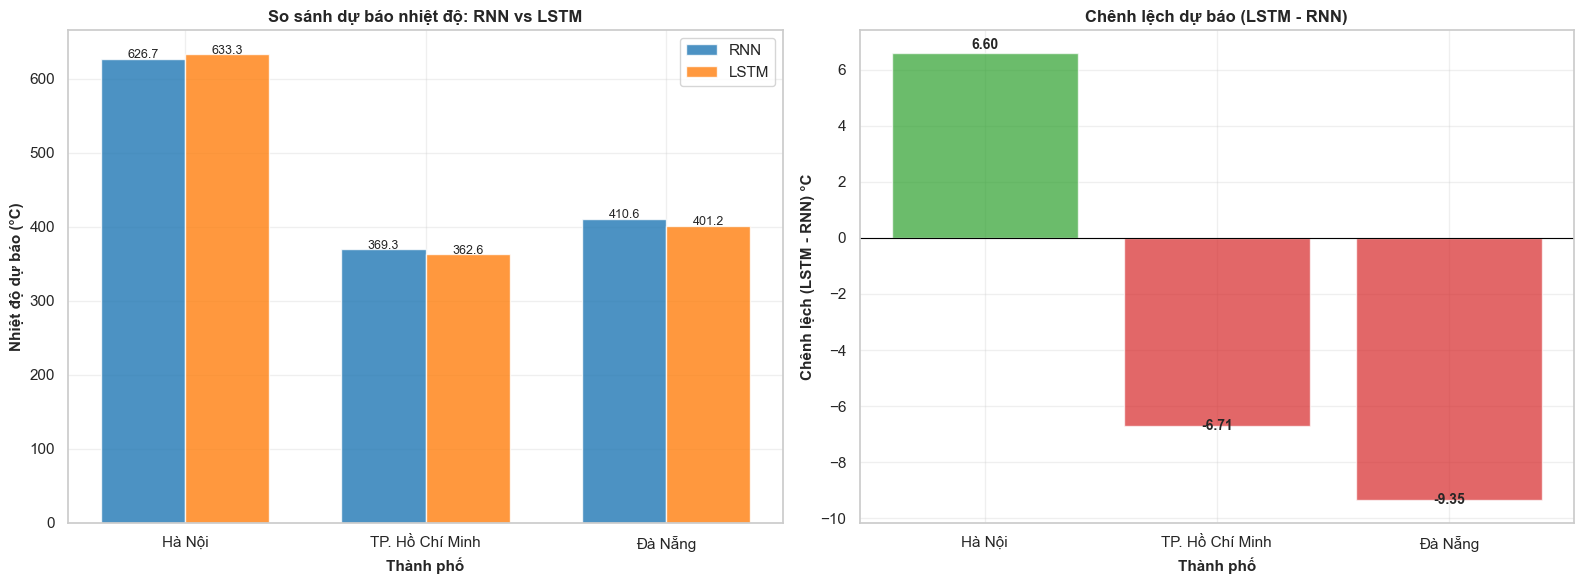

✅ So sánh dự báo hoàn tất!


In [17]:
# Cell #13: Vẽ 2 bản đồ so sánh RNN vs LSTM
# Đỗ Ngọc Lâm – B22DCCN476
# -------------------------------------------------------

# Tạo 2 bản đồ side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Lấy dữ liệu từ bảng so sánh
cities_list = df_comparison_pivot.index.tolist()
rnn_temps = df_comparison_pivot["RNN"].values
lstm_temps = df_comparison_pivot["LSTM"].values

x = np.arange(len(cities_list))
width = 0.35

# Biểu đồ 1: So sánh dự đoán RNN vs LSTM
ax1.bar(x - width/2, rnn_temps, width, label="RNN", color="#1f77b4", alpha=0.8)
ax1.bar(x + width/2, lstm_temps, width, label="LSTM", color="#ff7f0e", alpha=0.8)
ax1.set_xlabel("Thành phố", fontsize=11, fontweight='bold')
ax1.set_ylabel("Nhiệt độ dự báo (°C)", fontsize=11, fontweight='bold')
ax1.set_title("So sánh dự báo nhiệt độ: RNN vs LSTM", fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(cities_list)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Hiển thị giá trị trên cột
for i, (rnn, lstm) in enumerate(zip(rnn_temps, lstm_temps)):
    ax1.text(i - width/2, rnn + 0.5, f"{rnn:.1f}", ha='center', fontsize=9)
    ax1.text(i + width/2, lstm + 0.5, f"{lstm:.1f}", ha='center', fontsize=9)

# Biểu đồ 2: Chênh lệch giữa LSTM và RNN
differences = lstm_temps - rnn_temps
colors = ['#2ca02c' if d > 0 else '#d62728' for d in differences]
ax2.bar(cities_list, differences, color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel("Thành phố", fontsize=11, fontweight='bold')
ax2.set_ylabel("Chênh lệch (LSTM - RNN) °C", fontsize=11, fontweight='bold')
ax2.set_title("Chênh lệch dự báo (LSTM - RNN)", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Hiển thị giá trị chênh lệch
for i, (city, diff) in enumerate(zip(cities_list, differences)):
    ax2.text(i, diff + 0.15 if diff > 0 else diff - 0.15, f"{diff:.2f}", 
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ So sánh dự báo hoàn tất!")
